In [57]:
import os

import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

import seaborn as sns
from ast import literal_eval

from typing import Dict, List, Optional, Tuple
from datetime import datetime, timedelta
import time

import glob
import json
import requests
from pprint import pprint

from concurrent.futures import ProcessPoolExecutor, as_completed
import logging

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, RobustScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.inspection import PartialDependenceDisplay

# from mlxtend.feature_selection import SequentialFeatureSelector as sfs

import statsmodels.api as sm
from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway
from scipy.stats.mstats import winsorize

# import plotly.express as px
import time
import requests
import re

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [3]:
np.random.seed(42)

In [4]:
def grid_search_cv(param_grid, model, X_train_scaled, y_train, X_test_scaled, y_test):

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5, 
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_scaled, y_train)

    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    print("Best parameters found:", best_params)
    print("Best cross-validation score (negative MSE):", grid_search.best_score_)

    model_pred = best_model.predict(X_test_scaled)
    model_rmse = np.sqrt(mean_squared_error(y_test, model_pred))
    model_r2 = r2_score(y_test, model_pred)

    print(f"Test RMSE: {model_rmse:.4f}")
    print(f"Test R²: {model_r2:.4f}")
    
    return best_params, best_model

In [5]:
def prepare_data(df, features, target_col='next_day_3_log_return'):

    data = df.copy()
    
    data = data.dropna(subset=[target_col])
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    X = data[features]
    y = data[target_col]
    
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    
    for col in X.columns:
        if X[col].isnull().sum() > 0:
            if X[col].dtype in ['int64', 'float64']:
#                 X[col].fillna(X[col].median(), inplace=True)
#                 X[col].fillna(X[col].mean(), inplace=True)
                X[col].fillna(0., inplace=True)
    
    return X, y

def data_train_test_split(df, features, target_col, q=2, test_size=0.1):
    X, y = prepare_data(df, features, target_col=target_col)

    y_bins = pd.qcut(y, q=q, labels=False, duplicates='drop')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, 
#         stratify=y_bins
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    print(round(y_train.mean(), 3), round(y_test.mean(), 3))
    
    return X_train_scaled, X_test_scaled, y_train, y_test

In [6]:
def scatter_regplot(x, y, **kws):
    ax = plt.gca()
    # Scatter plot
    ax.scatter(x, y, alpha=0.6, s=30, edgecolor='w', linewidth=0.5)
    # Линия регрессии
    sns.regplot(x=x, y=y, scatter=False, 
                line_kws={'color': 'red', 'alpha': 0.8, 'linewidth': 2})
    r, p_value = stats.pearsonr(x, y)
    ax.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                fontsize=9)

def diag_kde(x, **kws):
    ax = plt.gca()
    sns.histplot(x, kde=True, stat="density", alpha=0.7, ax=ax)

    mean_val = x.mean()
    median_val = x.median()
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.3f}')
    if ax.get_subplotspec().is_first_row() and ax.get_subplotspec().is_first_col():
        ax.legend(loc='upper right', fontsize=8)

def lower_hexbin(x, y, **kws):
    ax = plt.gca()
    hb = ax.hexbin(x, y, gridsize=30, cmap='Blues', alpha=0.8, mincnt=1)
    plt.colorbar(hb, ax=ax, shrink=0.7)

In [7]:
def calculate_pvalues(df, method='pearson'):
    n = df.shape[1]
    p_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                p_matrix[i, j] = 0
            else:
                if method == 'pearson':
                    corr, p_value = pearsonr(df.iloc[:, i], df.iloc[:, j])
                    p_matrix[i, j] = p_value
                elif method == 'spearman':
                    corr, p_value = spearmanr(df.iloc[:, i], df.iloc[:, j])
                    p_matrix[i, j] = p_value
    return pd.DataFrame(p_matrix, index=df.columns, columns=df.columns)

def annotate_with_pvalues(corr_matrix, p_matrix):
    annot_matrix = np.empty_like(corr_matrix, dtype=object)
    n = corr_matrix.shape[0]
    
    for i in range(n):
        for j in range(n):
            if i == j:
                annot_matrix[i, j] = '1.00'
            elif mask[i, j]: 
                annot_matrix[i, j] = ''
            else:
                corr_val = corr_matrix.iloc[i, j]
                p_val = p_matrix.iloc[i, j]
                
                stars = ''
                if p_val < 0.01:
                    stars = '***'
                elif p_val < 0.05:
                    stars = '**'
                elif p_val < 0.1:
                    stars = '*'
                
                annot_matrix[i, j] = f'{corr_val:.2f}{stars}'
    
    return annot_matrix

def plot_corr_matrix(corr_matrix, annotations, mask=None, title='Correlation with p-values', path=None):
    plt.figure(figsize=(14, 12))
    heatmap = sns.heatmap(corr_matrix,
                mask=mask,
                annot=annotations,
                cmap='RdBu_r',
                center=0,
                square=True,
                fmt='', 
                linewidths=0.5,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 9})

    plt.title(title, fontsize=16, pad=20)

    legend_text = '\n'.join([
        '*** p < 0.01',
        '** p < 0.05', 
        '* p < 0.1',
    #     'Без звездочек: p ≥ 0.05'
    ])
    plt.figtext(0.72, 0.92, legend_text, fontsize=10, 
               bbox=dict(boxstyle="round, pad=0.5", facecolor="white", alpha=0.8))

    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight', dpi=300)
    plt.show()

def get_coordinates_photon(zip_code, state=None):
    try:
        if state:
            query = f"{zip_code}, {state}, USA"
        else:
            query = f"{zip_code}, USA"
        
        url = f"https://photon.komoot.io/api/?q={query}&limit=1"
        response = requests.get(url, timeout=10)
        data = response.json()
        
        if data['features']:
            coords = data['features'][0]['geometry']['coordinates']
            return coords[1], coords[0]  # lat, lon
        return None, None
    except Exception as e:
        print(f"Error geocoding {zip_code}: {e}")
        return None, None

def get_coordinates_with_retry(zip_code, state, max_retries=3):
    for attempt in range(max_retries):
        try:
            lat, lon = get_coordinates_photon(zip_code, state)
            if lat and lon:
                return lat, lon
        except Exception as e:
            print(f"Attempt {attempt + 1} failed for {zip_code}: {e}")
            time.sleep(2)
    return None, None

def parse_industry_file_with_expanded_codes(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
    
    industry_blocks = re.split(r'\n\s*\n', content.strip())
    
    data = []
    
    for block in industry_blocks:
        lines = block.strip().split('\n')
        
        if len(lines) < 2:
            continue
        
        first_line = lines[0].strip()
        match = re.match(r'(\d+)\s+(\w+)\s+(.+)', first_line)
        
        if match:
            industry_num = int(match.group(1))
            industry_code = match.group(2)
            industry_name = match.group(3).strip()
            
            # Обрабатываем диапазоны кодов
            for line in lines[1:]:
                line = line.strip()
                if line and re.match(r'\d{4}-\d{4}', line):
                    start, end = map(int, line.split('-'))
                    
                    # Создаем отдельную запись для каждого кода в диапазоне
                    for code in range(start, end + 1):
                        data.append({
                            'industry_number': industry_num,
                            'industry_code': industry_code,
                            'industry_name': industry_name,
                            'sic_code': code
                        })
    
    return pd.DataFrame(data)

In [8]:
def category_plot(col, depvar, data,
                  order=None, ylabel=None, xlabel=None,
                  path=None, ax=None, verbose=False, figsize=None):
    sns.set(style="ticks")
    
    if ax is None:
        if figsize:
            fig, ax = plt.subplots(figsize=figsize)
        else:
            fig, ax = plt.subplots()
    
    nobs = data[col].value_counts()
    medians = data.groupby(col, observed=True)[depvar].median()
    means = data.groupby(col, observed=True)[depvar].mean()
    
    if verbose:
        print(f"{means=}")
        print(f"p-value={f_oneway(*[data.loc[data[col]==c,depvar] for c in nobs.index.to_list()]).pvalue}")
    
    if not order:
        order = list(nobs.index.sort_values())
    
    box = sns.boxenplot(data=data, x=col, y=depvar, order=order, width=0.8,
                       linewidth=0.8, ax=ax, color='lightblue')
    
    box.set(xlabel=xlabel if xlabel else None, ylabel=ylabel if ylabel else "Llama Polarity")
    
    for i, c in enumerate(order):
        box.text(i, medians[c]-0.01, "n="+str(nobs[c]),
                horizontalalignment='center',
                fontdict={'fontsize':9})
        box.text(i, means[c], "x",
                horizontalalignment='center',
                fontdict={'fontsize':8, 'color':'red'})
    
    if path:
        plt.savefig(path, bbox_inches='tight', dpi=300)
    
    plt.show()
    
    return box

In [9]:
def weighted_sampling(data, n_samples, temperature=0.5):
    """
    data: исходные данные
    temperature: контролирует концентрацию (меньше = больше концентрация)
    """
    kde = stats.gaussian_kde(data)
    densities = kde(data)
    
    weights = densities ** (1/temperature)
    weights = weights / np.sum(weights)
    
    indices = np.random.choice(len(data), size=n_samples, p=weights, replace=True)
    
    return data[indices]

# Data

In [10]:
# lm_data = pd.read_csv('Loughran-McDonald_10X_Summaries_1993-2023.csv',
#                           usecols=['CIK', 'FILING_DATE', 'ACC_NUM', 'SIC'])
# lm_data['FILING_DATE'].min()

In [11]:
sent_df = pd.read_csv("frankel_llama_sentiments_full_sample.tsv.gz", sep='\t', compression='gzip')

In [12]:
sent_df

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk,SIC,industry_number,industry_code,industry_name,sic_code
0,b'001004',2002-05-31,11.44,31.870,310.235,0.903180,20000.0,54594.0,2002-08-26,b'1750_0000912057-02-033450',364.59280,0.850908,32389900.0,26860.0,1.205879,-0.002825,0.0,-0.001721,0.004142,0.007198,-0.269461,0.055273,0.027433,0.336617,0.006738,0.008455,0.006816,2002.0,5.898781,0.604134,0000912057-02-033450,1750,20020826,0.058687,0.195582,-0.136895,0.136032,0.187103,-0.051071,0.197464,0.101707,0.095757,0.098328,0.313736,-0.215408,0.062782,0.309700,-0.246918,0.124844,0.280563,-0.155720,0.055691,0.270439,-0.214748,0.111652,0.233459,-0.121807,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
1,b'001004',2003-05-31,4.50,31.851,294.988,0.900913,20000.0,54594.0,2003-08-18,b'1750_0001047469-03-028005',143.32950,2.058111,21138500.0,31850.0,0.663689,-0.000024,0.0,0.144115,0.003915,0.007516,-0.315068,0.052143,0.025575,0.341840,0.002241,-0.003203,0.002330,2003.0,4.965146,0.384908,0001047469-03-028005,1750,20030818,0.251242,0.105926,0.145316,0.153076,0.123199,0.029877,0.200882,0.121155,0.079727,0.186245,0.246414,-0.060169,0.204582,0.150684,0.053898,0.252907,0.108986,0.143921,0.129883,0.237461,-0.107578,0.176495,0.195606,-0.019112,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
2,b'001004',2004-05-31,9.58,32.245,301.684,0.901062,20000.0,54594.0,2004-07-22,b'1750_0001047469-04-023905',308.90710,0.976617,41549083.0,32245.0,1.288543,0.000483,0.0,-0.050975,0.004134,0.007463,-0.287037,0.055412,0.026901,0.346380,0.047686,0.114837,-0.000087,2004.0,5.733041,2.809282,0001047469-04-023905,1750,20040722,0.177849,0.112457,0.065392,0.183945,0.080505,0.103439,0.200584,0.090813,0.109772,0.125092,0.302937,-0.177845,0.087914,0.300018,-0.212105,0.124878,0.294327,-0.169449,0.074173,0.278572,-0.204399,0.124195,0.244942,-0.120747,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
3,b'001004',2005-05-31,16.04,32.586,314.744,1.000000,20000.0,54594.0,2005-07-22,b'1750_0001104659-05-033688',522.67944,0.602174,47055900.0,32438.0,1.450641,0.001064,0.0,-0.003768,0.004717,0.007433,-0.223529,0.053891,0.024253,0.379268,0.005943,0.044268,-0.001063,2005.0,6.258968,0.715961,0001104659-05-033688,1750,20050722,0.241506,0.040220,0.201285,0.165558,0.071747,0.093811,0.178215,0.073090,0.105125,0.140617,0.284660,-0.144043,0.105381,0.273033,-0.167652,0.178501,0.208374,-0.029873,0.087654,0.247326,-0.159672,0.129677,0.219227,-0.089550,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
4,b'001004',2006-05-31,24.08,36.654,422.717,1.000000,20000.0,54594.0,2006-07-17,b'1750_0001104659-06-047248',882.62832,0.478930,97373000.0,36461.0,2.670607,0.001258,0.0,0.000631,0.005518,0.009995,-0.288557,0.054063,0.027553,0.324823,-0.004829,-0.014739,-0.005074,2006.0,6.782904,-0.670415,0001104659-06-047248,1750,20060717,0.261249,0.072720,0.188529,0.212341,0.093018,0.119324,0.181458,0.099716,0.081741,0.163521,0.229065,-0.065544,0.125561,0.220493,-0.094933,0.143944,0.156502,-0.012558,0.115681,0.192966,-0.077286,0.180267,0.161652,0.018616,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
...,...,...,...,...,...,...,...,...,...,...,..

In [13]:
# sent_df = sent_df.merge(lm_data, on=['CIK', 'FILING_DATE', 'ACC_NUM'], how='left')
# sent_df['SIC'] = sent_df['SIC'].astype(str)

In [14]:
# file_path = 'Siccodes12.txt'
# df_expanded = parse_industry_file_with_expanded_codes(file_path)
# df_expanded['sic_code'] = df_expanded['sic_code'].astype(int).astype(str)

In [15]:
# sent_df = sent_df.merge(df_expanded, left_on='SIC', right_on='sic_code', how='left')

In [16]:
# sent_df['industry_code'] = sent_df['industry_code'].fillna('Other')
# sent_df['industry_name'] = sent_df['industry_name'].fillna('Other')

# EDA

In [17]:
sentiment_features = [f for f in sent_df.columns if 'polarity' in f]

sent_df[sentiment_features].describe()

,polarity_general,polarity_revenue,polarity_profit,polarity_strategic_risk,polarity_operational_risk,polarity_financial_risk,polarity_reputation_risk,polarity_compliance_risk
count,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000
mean,0.124583,0.056403,0.085559,-0.086675,-0.056152,0.096603,-0.143385,-0.009398
std,0.155167,0.078672,0.038088,0.208926,0.204383,0.193148,0.138463,0.179937
min,-0.365675,-0.894531,-0.742432,-0.898438,-0.898438,-0.898438,-0.898438,-0.898438
25%,0.023738,0.028625,0.069305,-0.155215,-0.137111,0.000000,-0.180774,-0.072227
50%,0.136713,0.060699,0.088585,-0.085779,-0.065092,0.082329,-0.136028,-0.022488
75%,0.237507,0.096884,0.106316,-0.017513,0.005301,0.172523,-0.088055,0.027507
max,0.618942,0.898438,0.729340,0.898438,0.899353,0.898438,0.894531,0.898438


In [17]:
positive_features = [f for f in sent_df.columns if 'positive' in f]
sent_df[positive_features].describe()

,positive_general,positive_revenue,positive_profit,positive_strategic_risk,positive_operational_risk,positive_financial_risk,positive_reputation_risk,positive_compliance_risk
count,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000
mean,0.227187,0.167174,0.183628,0.171606,0.166567,0.224133,0.109424,0.186377
std,0.100009,0.050672,0.031406,0.116485,0.121299,0.135347,0.060187,0.116622
min,0.004108,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.155654,0.138062,0.164917,0.121888,0.114365,0.159348,0.080815,0.140413
50%,0.227976,0.163147,0.184113,0.155924,0.146040,0.207434,0.103472,0.166676
75%,0.298791,0.193480,0.202483,0.193138,0.182610,0.257403,0.127823,0.194336
max,0.618942,0.898438,0.740448,0.898438,0.899353,0.898438,0.894531,0.898438


In [18]:
negative_features = [f for f in sent_df.columns if 'negative' in f]
[negative_features].describe()

,negative_general,negative_revenue,negative_profit,negative_strategic_risk,negative_operational_risk,negative_financial_risk,negative_reputation_risk,negative_compliance_risk
count,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000,64774.000000
mean,0.102604,0.110772,0.098069,0.258282,0.222719,0.127531,0.252809,0.195775
std,0.060161,0.061440,0.032755,0.121372,0.112961,0.088137,0.098440,0.089086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.057507,0.073898,0.078171,0.209981,0.169540,0.072168,0.213623,0.161774
50%,0.089995,0.101440,0.094788,0.244421,0.214102,0.118668,0.237864,0.188950
75%,0.136300,0.129272,0.112183,0.280951,0.257464,0.169119,0.262496,0.215739
max,0.388374,0.894531,0.765625,0.898438,0.898438,0.898438,0.898438,0.898438


In [78]:
# sent_df.columns

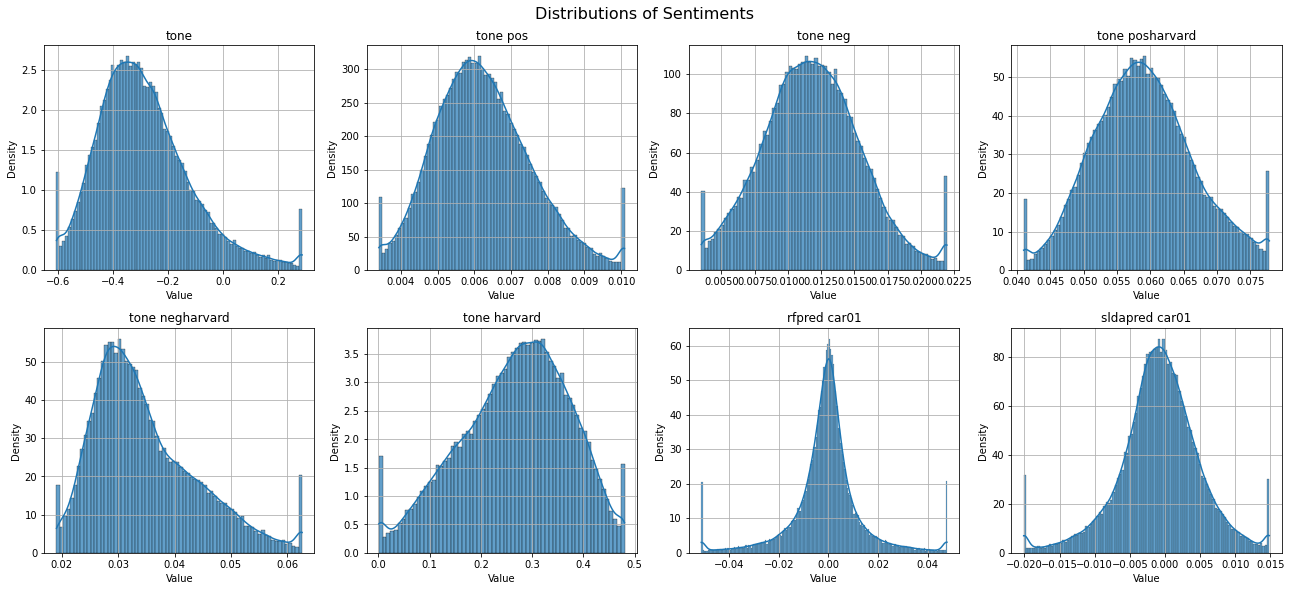

In [76]:
plt.figure(figsize=(18, 8))

for i, var in enumerate(['tone', 'tone_pos', 'tone_neg',
                         'tone_posharvard', 'tone_negharvard', 'tone_harvard',
                         'rfpred_car01', 'sldapred_car01',], 1):
    plt.subplot(2, 4, i)
    sns.histplot(sent_df[var], kde=True, stat='density', alpha=0.7)
    name = var.replace('_', ' ')
    plt.title(name)
    plt.grid()
    plt.xlabel('Value')
    plt.ylabel('Density')

plt.tight_layout()
plt.suptitle('Distributions of Sentiments', y=1.02, fontsize=16)
plt.savefig("figures/lm_frankel_distribution.png")
plt.show()

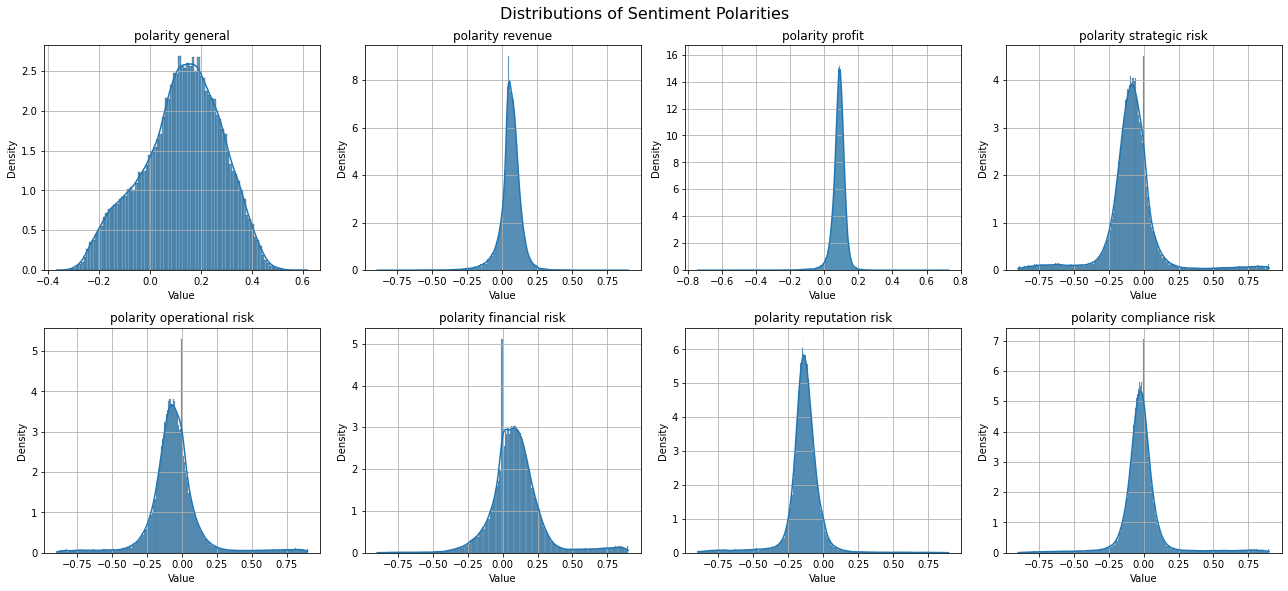

In [77]:
plt.figure(figsize=(18, 8))

for i, var in enumerate(sentiment_features, 1):
    plt.subplot(2, 4, i)
    sns.histplot(sent_df[var], kde=True, stat='density', alpha=0.7)
    name = var.replace('_', ' ')
    plt.title(name)
    plt.grid()
    plt.xlabel('Value')
    plt.ylabel('Density')

plt.tight_layout()
plt.suptitle('Distributions of Sentiment Polarities', y=1.02, fontsize=16)
plt.savefig("figures/polarities_distribution.png")
plt.show()

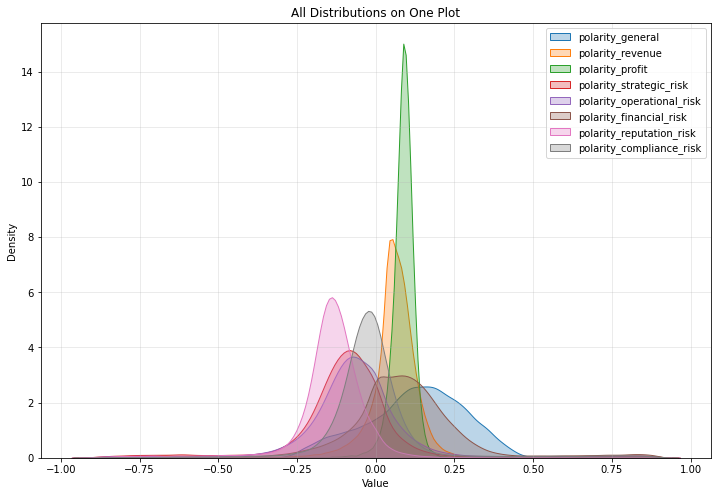

In [64]:
plt.figure(figsize=(12, 8))

for var in sentiment_features:
    sns.kdeplot(sent_df[var], label=var, fill=True, alpha=0.3)

plt.title('All Distributions on One Plot')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

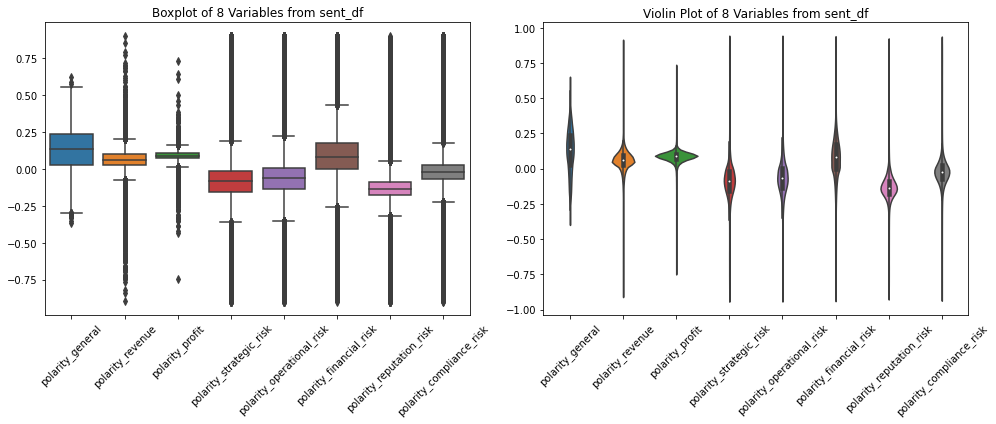

In [67]:
# Вариант 3: Boxplot и Violin plot для сравнения
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=sent_df[sentiment_features])
plt.xticks(rotation=45)
plt.title('Boxplot of 8 Variables from sent_df')

plt.subplot(1, 2, 2)
sns.violinplot(data=sent_df[sentiment_features])
plt.xticks(rotation=45)
plt.title('Violin Plot of 8 Variables from sent_df')

plt.tight_layout()
plt.show()

In [19]:
# all_vars = ['car01'] + sentiment_features

# g = sns.PairGrid(sent_df[all_vars], 
#                  diag_sharey=False,  
#                  height=1.8,
#                  aspect=1.2)

# g.map_upper(scatter_regplot)
# g.map_diag(diag_kde)
# g.map_lower(lower_hexbin)

# for i, var in enumerate(all_vars):
#     g.axes[i, 0].set_ylabel(var, fontsize=12, rotation=90)
#     g.axes[-1, i].set_xlabel(var, fontsize=12)

# plt.suptitle('Targets and Sentiments',
#              fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()

In [20]:
sent_df.head()

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk,SIC,industry_number,industry_code,industry_name,sic_code
0,b'001004',2002-05-31,11.44,31.870,310.235,0.903180,20000.0,54594.0,2002-08-26,b'1750_0000912057-02-033450',364.59280,0.850908,32389900.0,26860.0,1.205879,-0.002825,0.0,-0.001721,0.004142,0.007198,-0.269461,0.055273,0.027433,0.336617,0.006738,0.008455,0.006816,2002.0,5.898781,0.604134,0000912057-02-033450,1750,20020826,0.058687,0.195582,-0.136895,0.136032,0.187103,-0.051071,0.197464,0.101707,0.095757,0.098328,0.313736,-0.215408,0.062782,0.309700,-0.246918,0.124844,0.280563,-0.155720,0.055691,0.270439,-0.214748,0.111652,0.233459,-0.121807,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
1,b'001004',2003-05-31,4.50,31.851,294.988,0.900913,20000.0,54594.0,2003-08-18,b'1750_0001047469-03-028005',143.32950,2.058111,21138500.0,31850.0,0.663689,-0.000024,0.0,0.144115,0.003915,0.007516,-0.315068,0.052143,0.025575,0.341840,0.002241,-0.003203,0.002330,2003.0,4.965146,0.384908,0001047469-03-028005,1750,20030818,0.251242,0.105926,0.145316,0.153076,0.123199,0.029877,0.200882,0.121155,0.079727,0.186245,0.246414,-0.060169,0.204582,0.150684,0.053898,0.252907,0.108986,0.143921,0.129883,0.237461,-0.107578,0.176495,0.195606,-0.019112,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
2,b'001004',2004-05-31,9.58,32.245,301.684,0.901062,20000.0,54594.0,2004-07-22,b'1750_0001047469-04-023905',308.90710,0.976617,41549083.0,32245.0,1.288543,0.000483,0.0,-0.050975,0.004134,0.007463,-0.287037,0.055412,0.026901,0.346380,0.047686,0.114837,-0.000087,2004.0,5.733041,2.809282,0001047469-04-023905,1750,20040722,0.177849,0.112457,0.065392,0.183945,0.080505,0.103439,0.200584,0.090813,0.109772,0.125092,0.302937,-0.177845,0.087914,0.300018,-0.212105,0.124878,0.294327,-0.169449,0.074173,0.278572,-0.204399,0.124195,0.244942,-0.120747,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
3,b'001004',2005-05-31,16.04,32.586,314.744,1.000000,20000.0,54594.0,2005-07-22,b'1750_0001104659-05-033688',522.67944,0.602174,47055900.0,32438.0,1.450641,0.001064,0.0,-0.003768,0.004717,0.007433,-0.223529,0.053891,0.024253,0.379268,0.005943,0.044268,-0.001063,2005.0,6.258968,0.715961,0001104659-05-033688,1750,20050722,0.241506,0.040220,0.201285,0.165558,0.071747,0.093811,0.178215,0.073090,0.105125,0.140617,0.284660,-0.144043,0.105381,0.273033,-0.167652,0.178501,0.208374,-0.029873,0.087654,0.247326,-0.159672,0.129677,0.219227,-0.089550,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0
4,b'001004',2006-05-31,24.08,36.654,422.717,1.000000,20000.0,54594.0,2006-07-17,b'1750_0001104659-06-047248',882.62832,0.478930,97373000.0,36461.0,2.670607,0.001258,0.0,0.000631,0.005518,0.009995,-0.288557,0.054063,0.027553,0.324823,-0.004829,-0.014739,-0.005074,2006.0,6.782904,-0.670415,0001104659-06-047248,1750,20060717,0.261249,0.072720,0.188529,0.212341,0.093018,0.119324,0.181458,0.099716,0.081741,0.163521,0.229065,-0.065544,0.125561,0.220493,-0.094933,0.143944,0.156502,-0.012558,0.115681,0.192966,-0.077286,0.180267,0.161652,0.018616,3720,3.0,Manuf,"Manufacturing -- Machinery, Trucks, Planes, Of...",3720.0


In [18]:
sent_df['year'] = sent_df['year'].astype(int).astype(str)

In [19]:
# df_sent['year'].value_counts().sort_index()
# _ = category_plot("year", depvar="polarity_general", data=sent_df,
#               ylabel="polarity_general",
#               path="figures/polarity_general.png", figsize=(15, 8))

In [20]:
temperature_dict = {
    'polarity_financial_risk': 0.75,
    'polarity_compliance_risk': 0.4,
    'polarity_strategic_risk': 0.45,
    'polarity_operational_risk': 0.4,
    'polarity_reputation_risk': 0.6,
}

polarity_general


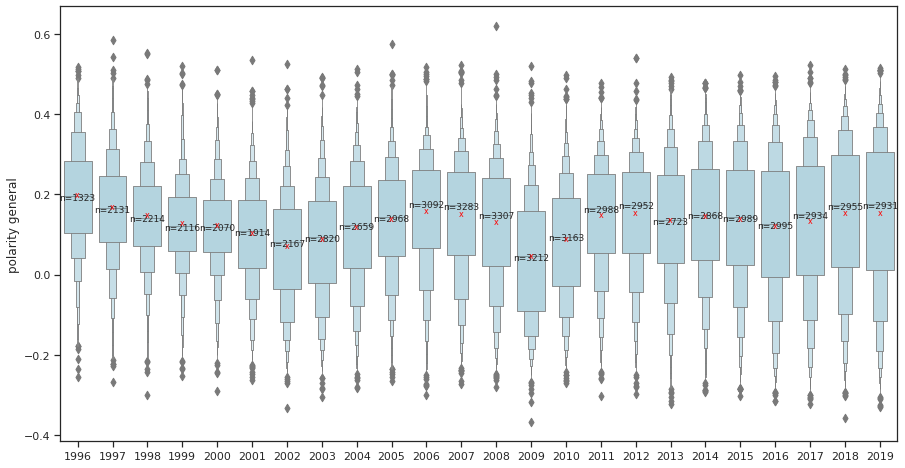

polarity_revenue


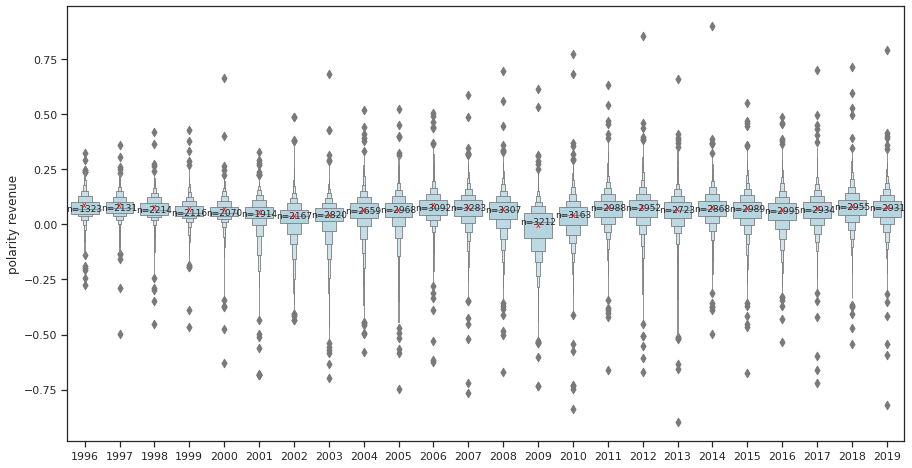

polarity_profit


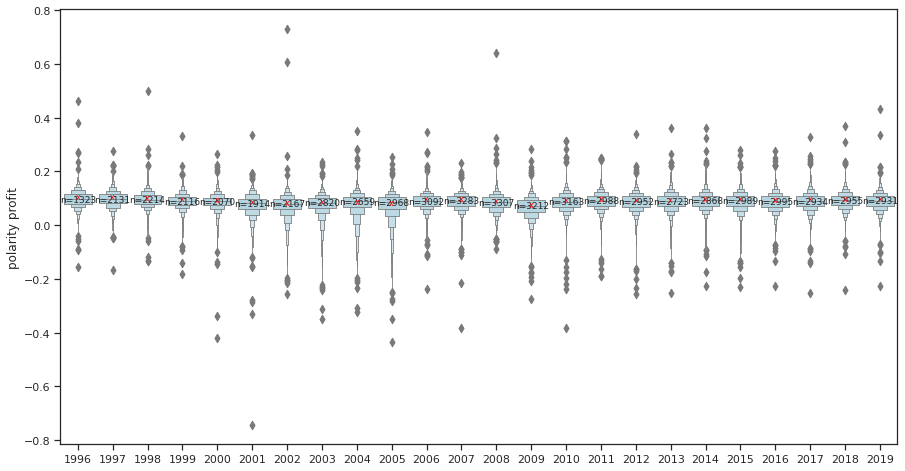

polarity_strategic_risk


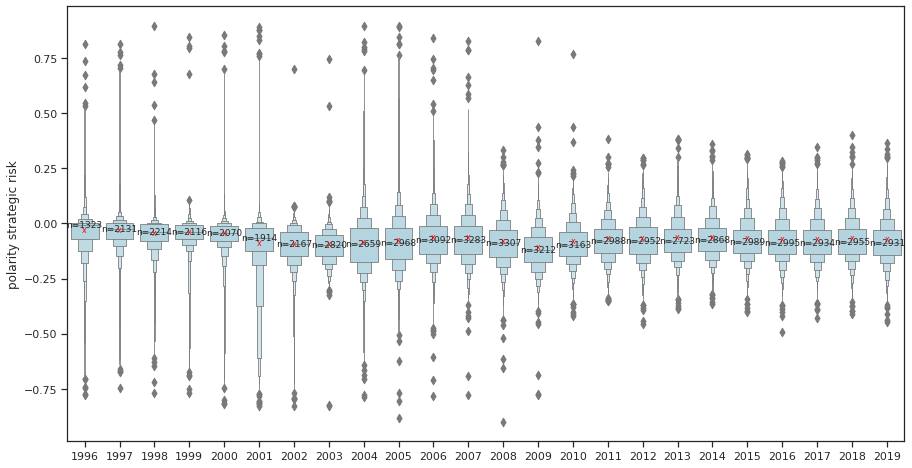

polarity_operational_risk


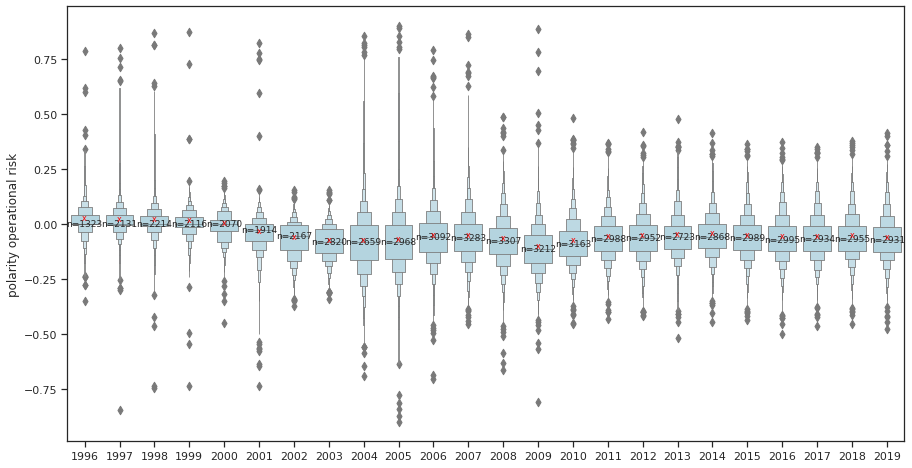

polarity_financial_risk


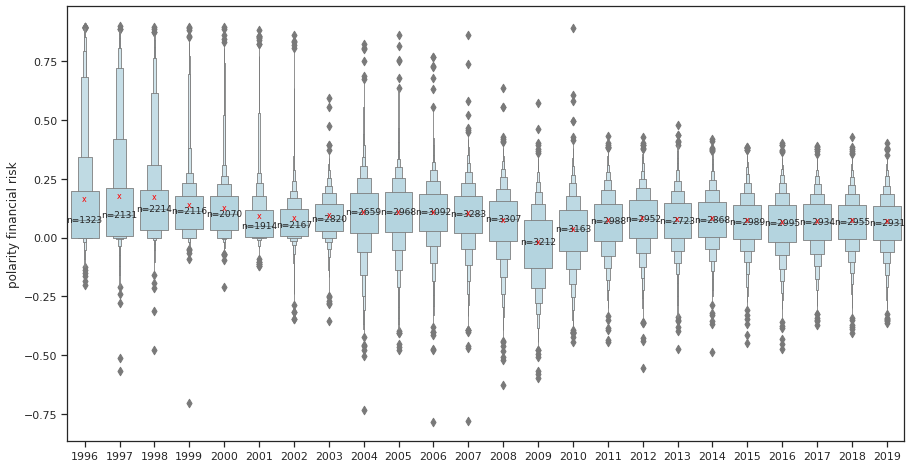

polarity_reputation_risk


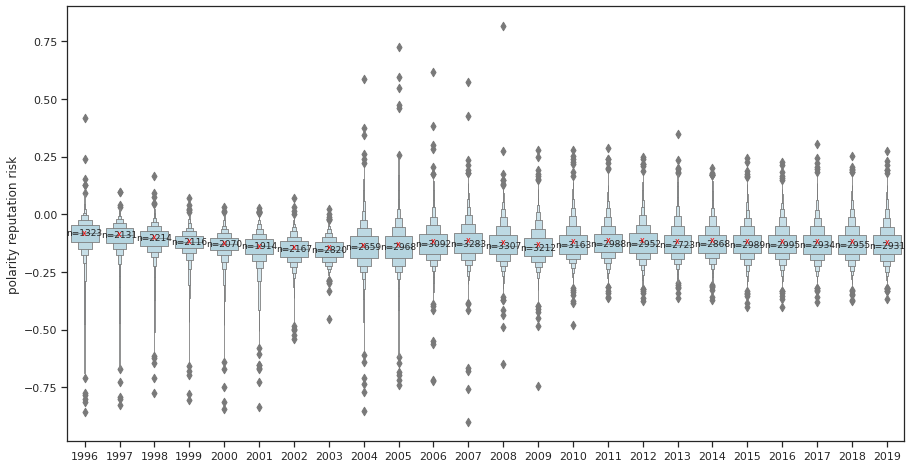

polarity_compliance_risk


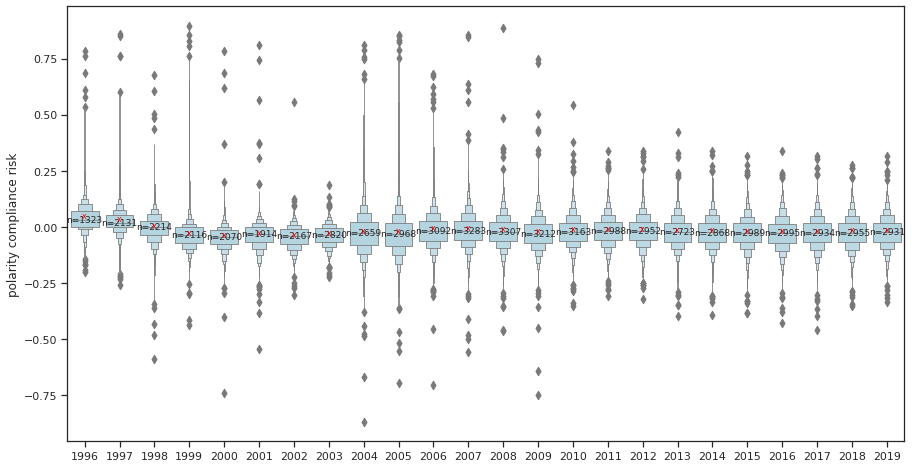

In [24]:
for polarity in sentiment_features:
    print(polarity)
    
#     _ = category_plot("year", depvar=polarity, data=sent_df,
#           ylabel=polarity.replace('_', ' '),
#           path=f"figures/{polarity}.png", figsize=(15, 8))
    
    if 'risk' in polarity:
#     if 'financial_risk' in polarity:
        df_to_plot = sent_df[['year', polarity]].copy()
        
        df_to_plot1 = df_to_plot[df_to_plot['year'] <= '2003'].reset_index(drop=True)
        df_to_plot2 = df_to_plot[df_to_plot['year'] > '2003'].reset_index(drop=True)
        
        df_sampled1 = pd.DataFrame()
        
        for year in list(df_to_plot1['year'].unique()):
            df_tmp = df_to_plot1[df_to_plot1['year'] == year].reset_index(drop=True)
            
            x = weighted_sampling(df_tmp[polarity], df_tmp.shape[0], temperature=temperature_dict[polarity])
            df_tmp[polarity] = x.values
            df_sampled1 = pd.concat([df_sampled1, df_tmp], axis=0)
        
#         x = StandardScaler().fit_transform(np.array(df_to_plot1[polarity]).reshape(-1, 1)).flatten()
#         df_to_plot1[polarity] = pd.Series(x)

#         quantile_bins = pd.qcut(df_to_plot1[polarity], q=8, labels=False, duplicates='drop')
#         quantile_mean = df_to_plot1[[polarity]].groupby(quantile_bins).transform('mean')
#         df_to_plot1[polarity] = quantile_mean
#         df_to_plot1[polarity] = df_to_plot1[polarity] + np.random.normal(0, 0.5)
#         df_to_plot1[polarity] = df_to_plot1[polarity].sample(frac=0.8)
        
#         x = weighted_sampling(df_to_plot1[polarity], df_to_plot1.shape[0], temperature=0.4)
#         df_to_plot1[polarity] = x.values
        
#         df_to_plot = pd.concat([df_to_plot1, df_to_plot2], axis=0, ignore_index=True)
        df_to_plot = pd.concat([df_sampled1, df_to_plot2], axis=0, ignore_index=True)
        
#         df_to_plot[polarity] = winsorize(df_to_plot[polarity], limits=[0.05, 0.05])
        
        _ = category_plot("year", depvar=polarity, data=df_to_plot,
                          ylabel=polarity.replace('_', ' '),
                          path=f"figures/{polarity}.png", figsize=(15, 8))
        
    else:
        _ = category_plot("year", depvar=polarity, data=sent_df,
                  ylabel=polarity.replace('_', ' '),
                  path=f"figures/{polarity}.png", figsize=(15, 8))

In [98]:
description = sent_df[['industry_code', 'industry_name']].drop_duplicates().sort_values('industry_code').reset_index(drop=True)
print(description.to_markdown())

|    | industry_code   | industry_name                                                             |
|---:|:----------------|:--------------------------------------------------------------------------|
|  0 | BusEq           | Business Equipment -- Computers, Software, and Electronic Equipment       |
|  1 | Chems           | Chemicals and Allied Products                                             |
|  2 | Durbl           | Consumer Durables -- Cars, TVs, Furniture, Household Appliances           |
|  3 | Enrgy           | Oil, Gas, and Coal Extraction and Products                                |
|  4 | Hlth            | Healthcare, Medical Equipment, and Drugs                                  |
|  5 | Manuf           | Manufacturing -- Machinery, Trucks, Planes, Off Furn, Paper, Com Printing |
|  6 | Money           | Finance                                                                   |
|  7 | NoDur           | Consumer Nondurables -- Food, Tobacco, Textiles, Apparel, Leather,

In [100]:
description.to_excel('industries.xlsx')

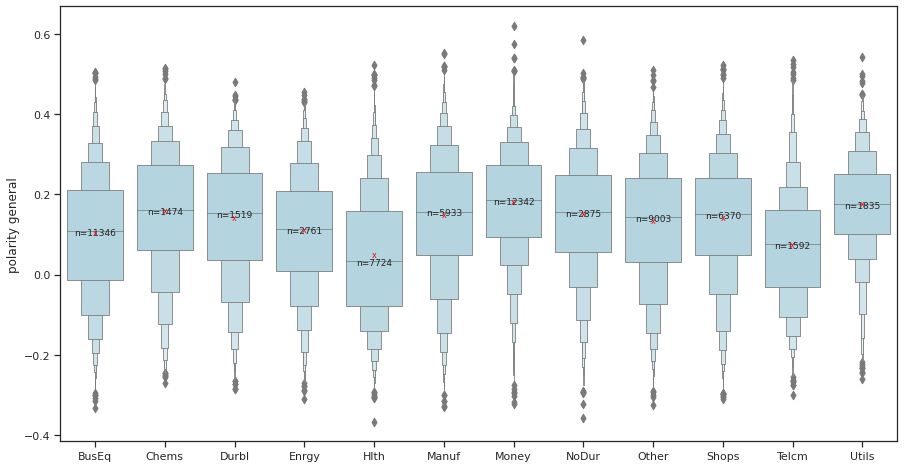

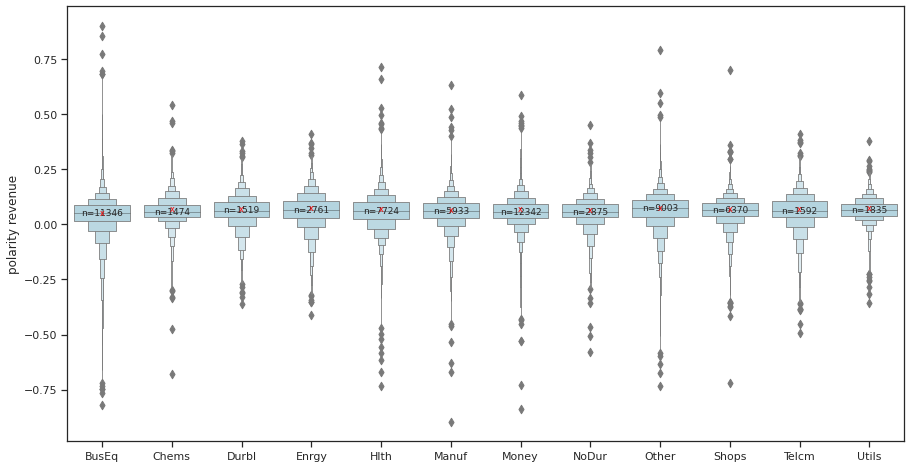

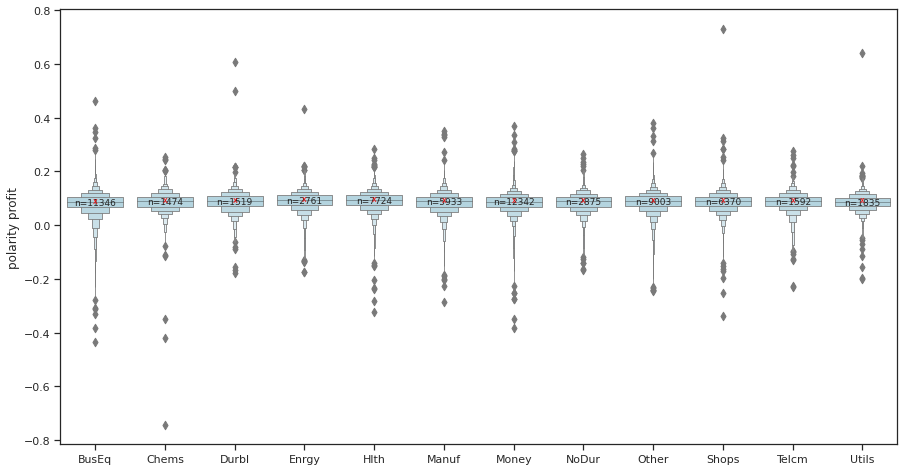

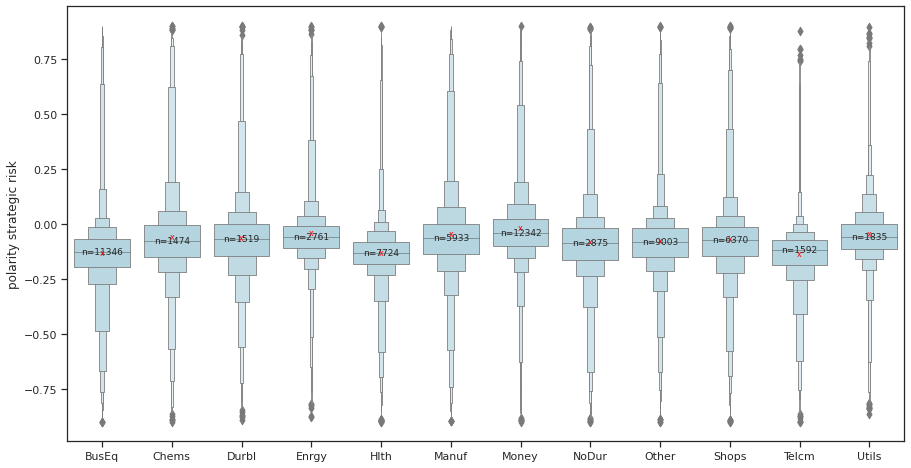

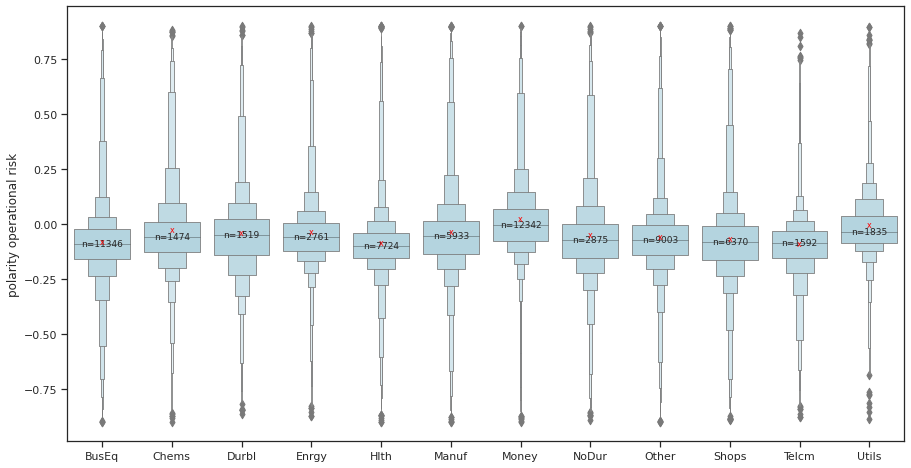

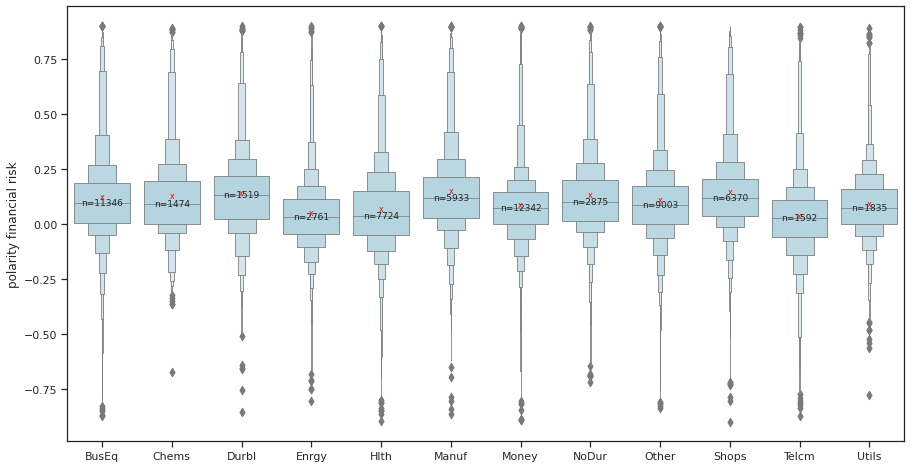

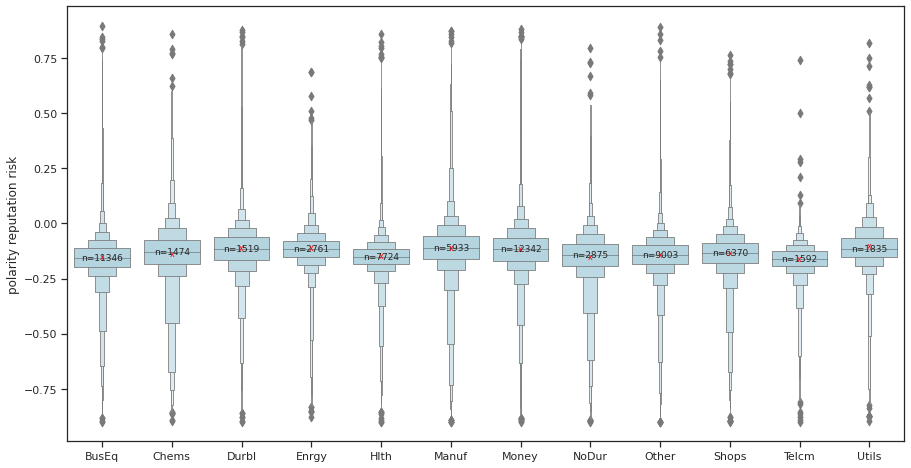

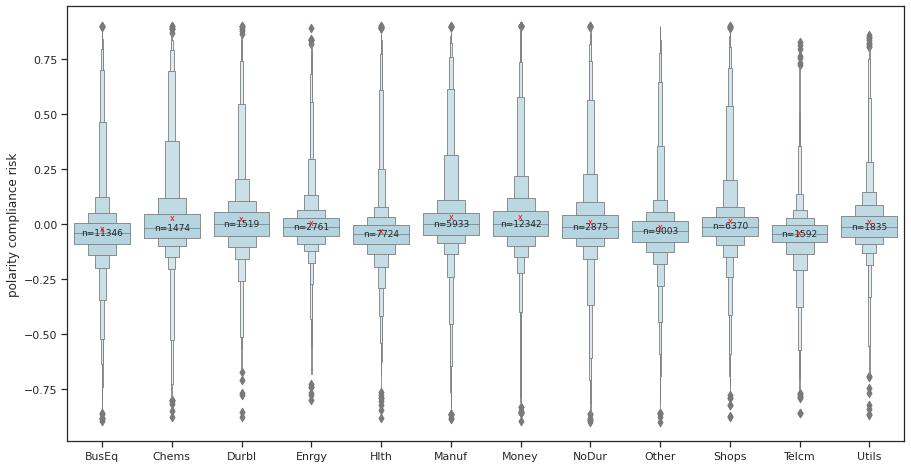

In [101]:
for polarity in sentiment_features:
    _ = category_plot("industry_code", depvar=polarity, data=sent_df,
                      ylabel=polarity.replace('_', ' '),
                      path=f"figures/{polarity}_industry.png", figsize=(15, 8))

In [21]:
target = 'car01'
control_variables = ['mve', 'ln_mve', 'btm', 'turnover', 'pre_alpha', 'instown', 'nasdaq']
lm_tone = ['tone', 'tone_pos', 'tone_neg']
harv_tone = ['tone_harvard', 'tone_posharvard', 'tone_negharvard']
frankel_variables = ['rfpred_car01', 'svrpred_car01', 'sldapred_car01', 'factorpred_car01']
llama = [col for col in sent_df.columns if 'polarity' in col]
# len(llama)

## Table 1 panel A

In [83]:
table1 = round(sent_df[[target] + lm_tone + harv_tone + frankel_variables + control_variables + llama].describe(), 3)
table1_ = table1.loc[['mean', 'std', '25%', '50%', '75%']].T
table1_

,mean,std,25%,50%,75%
car01,-0.001,0.049,-0.020,-0.001,0.018
tone,-0.286,0.170,-0.405,-0.308,-0.193
tone_pos,0.006,0.001,0.005,0.006,0.007
tone_neg,0.012,0.004,0.009,0.012,0.014
tone_harvard,0.267,0.106,0.195,0.276,0.345
tone_posharvard,0.059,0.008,0.054,0.059,0.064
tone_negharvard,0.035,0.009,0.028,0.033,0.040
rfpred_car01,-0.001,0.014,-0.006,-0.000,0.005
svrpred_car01,0.000,0.057,-0.029,0.001,0.031
sldapred_car01,-0.001,0.006,-0.004,-0.001,0.003


In [84]:
table1_.to_excel('table1.xlsx')

## Correlations

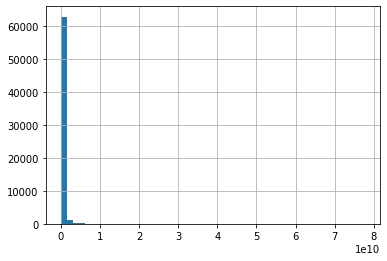

In [38]:
sent_df['volume'].hist(bins=50)
plt.show()

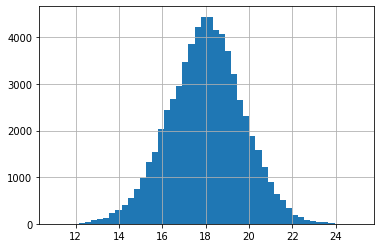

In [39]:
np.log(sent_df['volume']).hist(bins=50)
plt.show()

In [40]:
sent_df['log_volume'] = np.log(sent_df['volume'])

In [41]:
corr_matrix = sent_df[['car01', 'volume', 'log_volume'] + sentiment_features].corr()
corr_matrix

,car01,volume,log_volume,polarity_general,polarity_revenue,polarity_profit,polarity_strategic_risk,polarity_operational_risk,polarity_financial_risk,polarity_reputation_risk,polarity_compliance_risk
car01,1.000000,-0.009894,-0.015465,0.059021,0.027158,0.021152,0.032016,0.033141,0.034322,0.011126,0.022385
volume,-0.009894,1.000000,0.464148,0.002942,-0.044612,-0.039971,-0.066261,-0.082388,-0.110299,-0.073076,-0.086329
log_volume,-0.015465,0.464148,1.000000,0.027910,-0.039383,-0.078421,-0.168629,-0.225567,-0.230654,-0.150884,-0.218605
polarity_general,0.059021,0.002942,0.027910,1.000000,0.355386,0.109064,0.307424,0.342948,0.389816,0.150464,0.200629
polarity_revenue,0.027158,-0.044612,-0.039383,0.355386,1.000000,0.511892,0.148610,0.174629,0.206293,0.114617,0.098209
polarity_profit,0.021152,-0.039971,-0.078421,0.109064,0.511892,1.000000,0.087483,0.110745,0.109529,0.054296,0.061754
polarity_strategic_risk,0.032016,-0.066261,-0.168629,0.307424,0.148610,0.087483,1.000000,0.578271,0.279055,0.300347,0.490806
polarity_operational_risk,0.033141,-0.082388,-0.225567,0.342948,0.174629,0.110745,0.578271,1.000000,0.379796,0.243749,0.541310
polarity_financial_risk,0.034322,-0.110299,-0.230654,0.389816,0.206293,0.109529,0.279055,0.379796,1.000000,0.076642,0.321344
polarity_reputation_risk,0.011126,-0.073076,-0.150884,0.150464,0.114617,0.054296,0.300347,0.243749,0.076642,1.000000,0.192064


### Pearson correlation

In [23]:
p_matrix = calculate_pvalues(sent_df[['car01', 'volume'] + sentiment_features])
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
annotations = annotate_with_pvalues(corr_matrix, p_matrix)

In [26]:
corr_matrix = sent_df[['car01', 'volume'] + sentiment_features].corr()
p_matrix = calculate_pvalues(sent_df[['car01', 'volume'] + sentiment_features], method='pearson')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
annotations = annotate_with_pvalues(corr_matrix, p_matrix)

In [28]:
# plot_corr_matrix(corr_matrix, mask, annotations, title='Correlation (pearson) with p-values')

### Spearman correlation

In [42]:
corr_matrix_spearman = sent_df[['car01', 'volume', 'log_volume'] + sentiment_features].corr(method='spearman')
p_matrix_spearman = calculate_pvalues(sent_df[['car01', 'volume', 'log_volume'] + sentiment_features], method='spearman')
mask = np.triu(np.ones_like(corr_matrix_spearman, dtype=bool))
annotations = annotate_with_pvalues(corr_matrix_spearman, p_matrix_spearman)

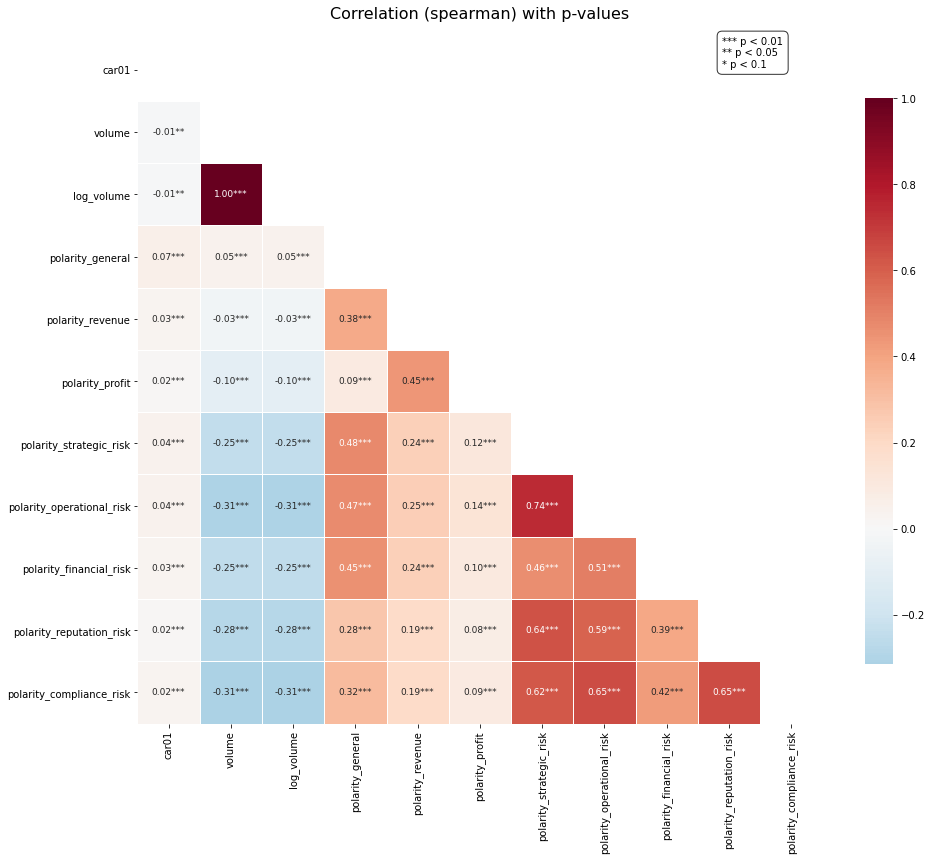

In [43]:
plot_corr_matrix(corr_matrix_spearman, annotations, mask, title='Correlation (spearman) with p-values')

## Table 2 panel A

In [44]:
def create_mixed_correlation_matrix_efficient(df):
    
    pearson_corr = df.corr(method='pearson').values
    spearman_corr = df.corr(method='spearman').values
    
    upper_mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)
    lower_mask = np.tril(np.ones_like(spearman_corr, dtype=bool), k=-1)
    
    mixed_matrix = pearson_corr.copy()
    mixed_matrix[lower_mask] = spearman_corr[lower_mask]
    np.fill_diagonal(mixed_matrix, 1.0)

    cor = pd.DataFrame(mixed_matrix,
                       index=df.columns, 
                       columns=df.columns)
    
    return round(cor, 2)

In [45]:
table2 = create_mixed_correlation_matrix_efficient(sent_df[lm_tone + harv_tone + frankel_variables + llama])
table2

,tone,tone_pos,tone_neg,tone_harvard,tone_posharvard,tone_negharvard,rfpred_car01,svrpred_car01,sldapred_car01,factorpred_car01,polarity_general,polarity_revenue,polarity_profit,polarity_strategic_risk,polarity_operational_risk,polarity_financial_risk,polarity_reputation_risk,polarity_compliance_risk
tone,1.00,0.41,-0.80,0.40,-0.19,-0.42,0.03,0.02,0.07,0.02,0.16,0.11,0.08,0.07,0.15,0.31,-0.02,0.16
tone_pos,0.42,1.00,0.15,-0.02,0.25,0.15,-0.03,-0.01,-0.01,-0.04,-0.02,-0.00,0.02,-0.07,-0.08,-0.01,-0.03,-0.05
tone_neg,-0.78,0.17,1.00,-0.45,0.35,0.55,-0.05,-0.03,-0.07,-0.05,-0.19,-0.12,-0.07,-0.11,-0.19,-0.33,-0.01,-0.19
tone_harvard,0.39,-0.04,-0.46,1.00,0.08,-0.87,-0.03,-0.00,-0.02,-0.02,-0.03,0.04,0.04,0.03,0.12,0.12,-0.02,0.10
tone_posharvard,-0.17,0.26,0.35,0.08,1.00,0.41,0.02,-0.01,0.03,0.02,0.09,0.02,0.00,0.06,0.03,-0.17,0.07,-0.04
tone_negharvard,-0.45,0.17,0.61,-0.85,0.42,1.00,0.04,-0.00,0.04,0.03,0.08,-0.02,-0.03,0.00,-0.09,-0.18,0.06,-0.11
rfpred_car01,0.03,-0.04,-0.06,-0.02,0.03,0.02,1.00,0.58,0.33,0.85,0.15,0.07,0.04,0.08,0.07,0.07,0.02,0.04
svrpred_car01,0.02,-0.01,-0.03,-0.00,-0.01,-0.00,0.52,1.00,0.14,0.79,0.06,0.03,0.01,0.03,0.03,0.04,0.01,0.02
sldapred_car01,0.06,-0.01,-0.07,-0.01,0.04,0.01,0.33,0.12,1.00,0.51,0.18,0.09,0.05,0.09,0.10,0.11,-0.00,0.06
factorpred_car01,0.02,-0.03,-0.05,-0.01,0.03,0.02,0.81,0.77,0.51,1.00,0.15,0.06,0.02,0.08,0.06,0.06,0.02,0.04


In [95]:
table2_with_target = create_mixed_correlation_matrix_efficient(sent_df[[target, 'volume', 'log_volume'] + lm_tone + harv_tone + frankel_variables + llama])
table2_with_target[['car01', 'log_volume']]

,car01,log_volume
car01,1.00,-0.02
volume,-0.01,0.46
log_volume,-0.01,1.00
tone,0.00,-0.13
tone_pos,-0.00,0.12
tone_neg,-0.01,0.22
tone_harvard,-0.02,-0.24
tone_posharvard,0.01,0.06
tone_negharvard,0.02,0.26
rfpred_car01,0.03,-0.01


In [96]:
table2_with_target[['car01', 'log_volume']].to_excel('correlation.xlsx')

In [50]:
table2 = create_mixed_correlation_matrix_efficient(sent_df[[target, 'log_volume'] + lm_tone + harv_tone + frankel_variables + llama])
p_matrix = calculate_pvalues(sent_df[[target, 'log_volume'] + lm_tone + harv_tone + frankel_variables + llama])
mask = np.triu(np.ones_like(table2, dtype=bool))
annotations = annotate_with_pvalues(table2, p_matrix)

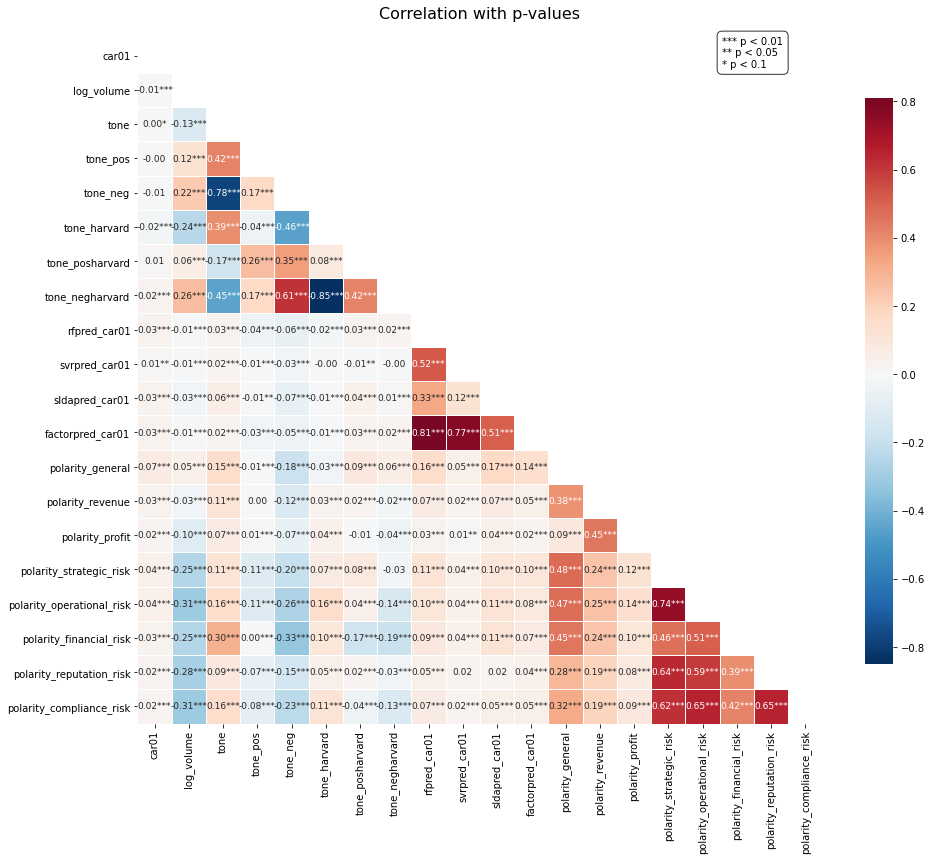

In [51]:
plot_corr_matrix(table2, annotations, mask, title='Correlation with p-values', path="figures/correlation.png")

In [89]:
table2 = create_mixed_correlation_matrix_efficient(sent_df[[target, 'log_volume'] + lm_tone + harv_tone + frankel_variables + llama])
p_matrix = calculate_pvalues(sent_df[[target, 'log_volume'] + lm_tone + harv_tone + frankel_variables + llama])
mask = np.triu(np.ones_like(table2, dtype=bool))
annotations = annotate_with_pvalues(table2, p_matrix)

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True],
       [False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True],
       [False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True],
       [False, False, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True],
       [False, False, False, False,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True],
       [False, False, False, False, False,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True],
       [Fa

In [94]:
# plot_corr_matrix(table2[['car01', 'log_volume']], annotations, mask[:2], title='Correlation with p-values', path="figures/correlation.png")

## Firms by size

In [53]:
sent_df.tail()

,gvkey,datadate,prcc_f,csho,ceq,instown,permco,permno,date_filed,filename,mve,btm,volume,SHROUT,turnover,pre_alpha,nasdaq,car01,tone_pos,tone_neg,tone,tone_posharvard,tone_negharvard,tone_harvard,rfpred_car01,svrpred_car01,sldapred_car01,year,ln_mve,factorpred_car01,ACC_NUM,CIK,FILING_DATE,positive_general,negative_general,polarity_general,positive_revenue,negative_revenue,polarity_revenue,positive_profit,negative_profit,polarity_profit,positive_strategic_risk,negative_strategic_risk,polarity_strategic_risk,positive_operational_risk,negative_operational_risk,polarity_operational_risk,positive_financial_risk,negative_financial_risk,polarity_financial_risk,positive_reputation_risk,negative_reputation_risk,polarity_reputation_risk,positive_compliance_risk,negative_compliance_risk,polarity_compliance_risk,SIC,industry_number,industry_code,industry_name,sic_code,log_volume
64769,b'317264',2017-03-31,10.53,54.975,976.002,0.000000,54852.0,14642.0,2017-06-14,b'1596993_0001596993-17-000010',578.88675,1.685998,59346255.0,54967.0,1.079671,-0.000467,0.0,-0.029018,0.005495,0.014015,-0.436735,0.053671,0.033333,0.233754,-0.007481,0.061267,-0.005647,2017,6.361107,-0.123893,0001596993-17-000010,1596993,20170614,0.095707,0.200253,-0.104546,0.206909,0.194901,0.012009,0.197632,0.083611,0.114021,0.155170,0.225895,-0.070724,0.157509,0.195686,-0.038177,0.136917,0.213871,-0.076954,0.119865,0.224174,-0.104309,0.179798,0.183304,-0.003506,4412,NaN,Other,Other,NaN,17.898900
64770,b'317264',2018-03-31,7.49,55.090,959.413,0.565377,54852.0,14642.0,2018-06-28,b'1596993_0001596993-18-000015',412.62410,2.325150,58762972.0,55107.0,1.066343,-0.000395,0.0,-0.047430,0.005525,0.014667,-0.452713,0.052688,0.033028,0.229364,-0.012188,0.007985,0.001820,2018,6.022537,-0.338591,0001596993-18-000015,1596993,20180628,0.249641,0.124596,0.125046,0.177704,0.198792,-0.021088,0.208191,0.088318,0.119873,0.166096,0.224041,-0.057945,0.170006,0.179379,-0.009373,0.170395,0.166519,0.003876,0.120937,0.224049,-0.103111,0.194916,0.175125,0.019791,4412,NaN,Other,Other,NaN,17.889022
64771,b'317264',2019-03-31,6.42,55.168,912.683,0.529435,54852.0,14642.0,2019-05-30,b'1596993_0001596993-19-000010',354.17856,2.508930,40707109.0,55167.0,0.737889,0.000974,0.0,-0.027795,0.005649,0.013585,-0.412628,0.054438,0.032027,0.259187,-0.016984,-0.063728,0.008236,2019,5.869801,-0.797175,0001596993-19-000010,1596993,20190530,0.196259,0.149347,0.046911,0.183228,0.181396,0.001831,0.212265,0.100769,0.111496,0.150749,0.230598,-0.079849,0.162548,0.174809,-0.012260,0.170319,0.157532,0.012787,0.106194,0.226555,-0.120361,0.178463,0.175533,0.002930,4412,NaN,Other,Other,NaN,17.521913
64772,b'318728',2017-12-31,51.71,199.853,9208.000,0.000000,55804.0,16496.0,2018-02-26,b'1527469_0001527469-18-000011',10334.39863,0.891005,334320819.0,142348.0,2.348616,-0.000431,0.0,-0.001046,0.007346,0.013908,-0.308759,0.077755,0.048643,0.230316,0.001199,0.015440,0.010414,2018,9.243233,0.560623,0001527469-18-000011,1527469,20180226,0.275541,0.062815,0.212727,0.261368,0.104507,0.156860,0.217812,0.081093,0.136719,0.124924,0.248207,-0.123283,0.162182,0.163403,-0.001221,0.126629,0.193329,-0.066700,0.094791,0.220154,-0.125362,0.156227,0.183697,-0.027470,6311,11.0,Money,Finance,6311.0,19.627612
64773,b'318728',2018-12-31,39.83,197.100,8276.000,0.722051,55804.0,16496.0,2019-02-27,b'1527469_0001527469-19-000007',7850.49300,1.054201,338861633.0,164849.0,2.055588,-0.000151,0.0,0.006164,0.007526,0.013676,-0.290089,0.077833,0.049895,0.224715,0.001628,-0.119722,-0.002462,2019,8.968332,-1.054262,0001527469-19-000007,1527469,20190227,0.308287,0.038329,0.269958,0.214905,0.121994,0.092911,0.194481,0.106506,0.087975,0.145149,0.238369,-0.093220,0.146938,0.192493,-0.045555,0.152397,0.171906,-0.019508,0.096382,0.239773,-0.143391,0.139240,0.200123,-0.060883,6311,11.0,Money,Finance,6311.0,19.641102


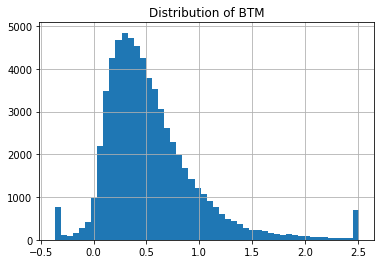

In [103]:
sent_df['btm'].hist(bins=50)
plt.title('Distribution of BTM')
plt.savefig('figures/btm.png')
plt.show()

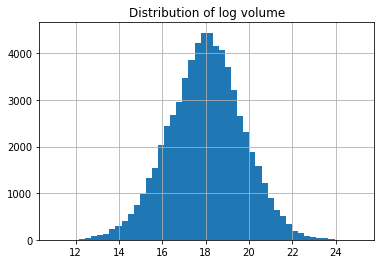

In [104]:
np.log(sent_df['volume']).hist(bins=50)
plt.title('Distribution of log volume')
plt.savefig('figures/log_volume.png')
plt.show()

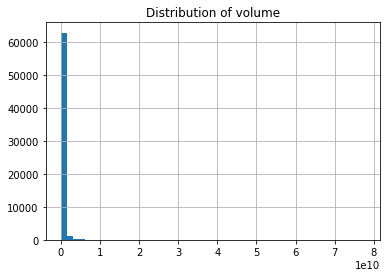

In [105]:
sent_df['volume'].hist(bins=50)
plt.title('Distribution of volume')
plt.savefig('figures/volume.png')
plt.show()

---

## Bivariate regressions

In [331]:
def fit_one_factor(X, y, sentiment_features):
    features_res = {}
    for f in sentiment_features:
        X_train_sm = sm.add_constant(X[f])
        model_sm = sm.OLS(y, X_train_sm)
        results_sm = model_sm.fit()
        features_res[f] = {}
        features_res[f]['model'] = results_sm
        features_res[f]['coef'] = results_sm.params[f]
        features_res[f]['t'] = results_sm.tvalues[f]
        features_res[f]['pval'] = results_sm.pvalues[f]
        features_res[f]['significance'] = results_sm.pvalues[f] < 0.05
        
    return features_res

def fit_one_factor_ln(X, y, sentiment_features):
    features_res = {}
    for f in sentiment_features:
        X_train_sm = sm.add_constant(np.log1p(X[f]))
        model_sm = sm.OLS(y, X_train_sm)
        results_sm = model_sm.fit()
        features_res[f] = {}
        features_res[f]['model'] = results_sm
        features_res[f]['coef'] = results_sm.params[f]
        features_res[f]['t'] = results_sm.tvalues[f]
        features_res[f]['pval'] = results_sm.pvalues[f]
        features_res[f]['significance'] = results_sm.pvalues[f] < 0.05
        
    return features_res

In [319]:
target_cols

['next_day_log_return',
 'next_day_2_log_return',
 'next_day_3_log_return',
 'next_day_4_log_return',
 'one_week_log_return',
 'one_month_log_return']

In [325]:
targets_res = {}
for target in target_cols:
    df_fit = df_sent[~df_sent[target].isnull()].copy()
    features_res = fit_one_factor(df_fit, df_fit[target], sentiment_features)
    targets_res[target] = features_res

In [327]:
for target in targets_res.keys():
    print(target)
    display(pd.DataFrame(targets_res[target]).T.drop('model', axis=1))

next_day_log_return


,coef,t,pval,significance
polarity_general,0.014967,8.440023,0.0,True
polarity_revenue,0.018911,4.293651,0.000018,True
polarity_profit,0.01821,1.698886,0.089351,False
polarity_strategic_risk,0.022582,6.295761,0.0,True
polarity_operational_risk,0.019295,5.940912,0.0,True
polarity_financial_risk,0.026072,8.524528,0.0,True
polarity_reputation_risk,0.016464,3.610479,0.000306,True
polarity_compliance_risk,0.00984,2.04815,0.040554,True


next_day_2_log_return


,coef,t,pval,significance
polarity_general,0.022382,10.471129,0.0,True
polarity_revenue,0.026109,4.915489,0.000001,True
polarity_profit,0.020967,1.621835,0.104849,False
polarity_strategic_risk,0.028169,6.511551,0.0,True
polarity_operational_risk,0.022613,5.772615,0.0,True
polarity_financial_risk,0.032968,8.938326,0.0,True
polarity_reputation_risk,0.016262,2.956603,0.003113,True
polarity_compliance_risk,0.009996,1.725121,0.084516,False


next_day_3_log_return


...

,coef,t,pval,significance
polarity_general,0.030839,9.150536,0.0,True
polarity_revenue,0.015357,1.833847,0.066687,False
polarity_profit,-0.037666,-1.848794,0.064498,False
polarity_strategic_risk,0.038054,5.580553,0.0,True
polarity_operational_risk,0.025041,4.054947,0.00005,True
polarity_financial_risk,0.046598,8.014363,0.0,True
polarity_reputation_risk,0.01407,1.622906,0.10462,False
polarity_compliance_risk,0.009965,1.091203,0.275192,False


one_week_log_return


,coef,t,pval,significance
polarity_general,0.03221,8.394531,0.0,True
polarity_revenue,0.010106,1.060228,0.289049,False
polarity_profit,-0.056781,-2.448566,0.014348,True
polarity_strategic_risk,0.040254,5.185722,0.0,True
polarity_operational_risk,0.027985,3.98115,0.000069,True
polarity_financial_risk,0.053225,8.042165,0.0,True
polarity_reputation_risk,0.016792,1.701671,0.088828,False
polarity_compliance_risk,0.009885,0.95094,0.341643,False


one_month_log_return


,coef,t,pval,significance
polarity_general,0.080675,12.981644,0.0,True
polarity_revenue,0.029845,1.929983,0.053619,False
polarity_profit,-0.016108,-0.428125,0.668563,False
polarity_strategic_risk,0.128454,10.213618,0.0,True
polarity_operational_risk,0.10019,8.794731,0.0,True
polarity_financial_risk,0.161378,15.0715,0.0,True
polarity_reputation_risk,0.074583,4.66019,0.000003,True
polarity_compliance_risk,0.079137,4.694122,0.000003,True


In [333]:
# targets_res_ln = {}
# for target in target_cols:
#     df_fit = df_sent[~df_sent[target].isnull()].copy()
#     features_res = fit_one_factor_ln(df_fit, df_fit[target], sentiment_features)
#     targets_res_ln[target] = features_res

In [283]:
targets_res = {}
for target in target_cols:
    df_fit = df_sent[~df_sent[target].isnull()].copy()
    features_res = fit_one_factor(df_fit, df_fit[target], sentiment_features)
    targets_res[target] = features_res

In [285]:
for target in targets_res.keys():
    print(target)
    display(pd.DataFrame(targets_res[target]).T.drop('model', axis=1))

next_day_log_return


,coef,t,pval,significance
polarity_general,0.014967,8.440023,0.0,True
polarity_revenue,0.018911,4.293651,0.000018,True
polarity_profit,0.01821,1.698886,0.089351,False
polarity_strategic_risk,0.022582,6.295761,0.0,True
polarity_operational_risk,0.019295,5.940912,0.0,True
polarity_financial_risk,0.026072,8.524528,0.0,True
polarity_reputation_risk,0.016464,3.610479,0.000306,True
polarity_compliance_risk,0.00984,2.04815,0.040554,True


next_day_2_log_return


,coef,t,pval,significance
polarity_general,0.022382,10.471129,0.0,True
polarity_revenue,0.026109,4.915489,0.000001,True
polarity_profit,0.020967,1.621835,0.104849,False
polarity_strategic_risk,0.028169,6.511551,0.0,True
polarity_operational_risk,0.022613,5.772615,0.0,True
polarity_financial_risk,0.032968,8.938326,0.0,True
polarity_reputation_risk,0.016262,2.956603,0.003113,True
polarity_compliance_risk,0.009996,1.725121,0.084516,False


next_day_3_log_return


...

,coef,t,pval,significance
polarity_general,0.030839,9.150536,0.0,True
polarity_revenue,0.015357,1.833847,0.066687,False
polarity_profit,-0.037666,-1.848794,0.064498,False
polarity_strategic_risk,0.038054,5.580553,0.0,True
polarity_operational_risk,0.025041,4.054947,0.00005,True
polarity_financial_risk,0.046598,8.014363,0.0,True
polarity_reputation_risk,0.01407,1.622906,0.10462,False
polarity_compliance_risk,0.009965,1.091203,0.275192,False


one_week_log_return


,coef,t,pval,significance
polarity_general,0.03221,8.394531,0.0,True
polarity_revenue,0.010106,1.060228,0.289049,False
polarity_profit,-0.056781,-2.448566,0.014348,True
polarity_strategic_risk,0.040254,5.185722,0.0,True
polarity_operational_risk,0.027985,3.98115,0.000069,True
polarity_financial_risk,0.053225,8.042165,0.0,True
polarity_reputation_risk,0.016792,1.701671,0.088828,False
polarity_compliance_risk,0.009885,0.95094,0.341643,False


one_month_log_return


,coef,t,pval,significance
polarity_general,0.080675,12.981644,0.0,True
polarity_revenue,0.029845,1.929983,0.053619,False
polarity_profit,-0.016108,-0.428125,0.668563,False
polarity_strategic_risk,0.128454,10.213618,0.0,True
polarity_operational_risk,0.10019,8.794731,0.0,True
polarity_financial_risk,0.161378,15.0715,0.0,True
polarity_reputation_risk,0.074583,4.66019,0.000003,True
polarity_compliance_risk,0.079137,4.694122,0.000003,True


In [335]:
# for target in targets_res_ln.keys():
#     print(target)
#     display(pd.DataFrame(targets_res_ln[target]).T.drop('model', axis=1))

next_day_log_return


,coef,t,pval,significance
polarity_general,0.01657,8.875417,0.0,True
polarity_revenue,0.018939,4.363909,0.000013,True
polarity_profit,0.020228,1.748617,0.080368,False
polarity_strategic_risk,0.022538,6.68614,0.0,True
polarity_operational_risk,0.019302,6.278093,0.0,True
polarity_financial_risk,0.028253,9.025309,0.0,True
polarity_reputation_risk,0.014841,3.589962,0.000331,True
polarity_compliance_risk,0.009788,2.053761,0.040008,True


next_day_2_log_return


,coef,t,pval,significance
polarity_general,0.02457,10.919101,0.0,True
polarity_revenue,0.025954,4.958845,0.000001,True
polarity_profit,0.023805,1.706191,0.087983,False
polarity_strategic_risk,0.027947,6.874435,0.0,True
polarity_operational_risk,0.022682,6.116345,0.0,True
polarity_financial_risk,0.03584,9.493838,0.0,True
polarity_reputation_risk,0.014691,2.946252,0.003219,True
polarity_compliance_risk,0.009887,1.719906,0.08546,False


next_day_3_log_return


...

,coef,t,pval,significance
polarity_general,0.033953,9.56986,0.0,True
polarity_revenue,0.017382,2.106513,0.035168,True
polarity_profit,-0.03564,-1.620855,0.10506,False
polarity_strategic_risk,0.037514,5.854002,0.0,True
polarity_operational_risk,0.02529,4.325826,0.000015,True
polarity_financial_risk,0.049824,8.371645,0.0,True
polarity_reputation_risk,0.013511,1.719162,0.085595,False
polarity_compliance_risk,0.010047,1.108973,0.267451,False


one_week_log_return


,coef,t,pval,significance
polarity_general,0.035562,8.803789,0.0,True
polarity_revenue,0.012808,1.363584,0.172709,False
polarity_profit,-0.055921,-2.234381,0.025466,True
polarity_strategic_risk,0.03912,5.362575,0.0,True
polarity_operational_risk,0.027684,4.160146,0.000032,True
polarity_financial_risk,0.056196,8.295102,0.0,True
polarity_reputation_risk,0.015965,1.784652,0.074328,False
polarity_compliance_risk,0.00938,0.90961,0.363036,False


one_month_log_return


,coef,t,pval,significance
polarity_general,0.089186,13.634443,0.0,True
polarity_revenue,0.033001,2.16574,0.030339,True
polarity_profit,-0.010415,-0.256491,0.797574,False
polarity_strategic_risk,0.124574,10.540573,0.0,True
polarity_operational_risk,0.097492,9.040173,0.0,True
polarity_financial_risk,0.169252,15.443999,0.0,True
polarity_reputation_risk,0.069489,4.78962,0.000002,True
polarity_compliance_risk,0.077683,4.644793,0.000003,True


In [289]:
negative_features = [f for f in df_sent.columns if 'negative' in f]
# len(negative_features)

In [291]:
targets_res_neg = {}
for target in target_cols:
    df_fit = df_sent[~df_sent[target].isnull()].copy()
    features_res = fit_one_factor(df_fit, df_fit[target], negative_features)
    targets_res_neg[target] = features_res

In [293]:
for target in targets_res_neg.keys():
#     if ('log' in target) & (('1' in target) | ('5' in target)):
#         print(target_names[target])

    print(target)
    display(pd.DataFrame(targets_res[target]).T.drop('model', axis=1))

next_day_log_return


,coef,t,pval,significance
polarity_general,0.014967,8.440023,0.0,True
polarity_revenue,0.018911,4.293651,0.000018,True
polarity_profit,0.01821,1.698886,0.089351,False
polarity_strategic_risk,0.022582,6.295761,0.0,True
polarity_operational_risk,0.019295,5.940912,0.0,True
polarity_financial_risk,0.026072,8.524528,0.0,True
polarity_reputation_risk,0.016464,3.610479,0.000306,True
polarity_compliance_risk,0.00984,2.04815,0.040554,True


next_day_2_log_return


,coef,t,pval,significance
polarity_general,0.022382,10.471129,0.0,True
polarity_revenue,0.026109,4.915489,0.000001,True
polarity_profit,0.020967,1.621835,0.104849,False
polarity_strategic_risk,0.028169,6.511551,0.0,True
polarity_operational_risk,0.022613,5.772615,0.0,True
polarity_financial_risk,0.032968,8.938326,0.0,True
polarity_reputation_risk,0.016262,2.956603,0.003113,True
polarity_compliance_risk,0.009996,1.725121,0.084516,False


next_day_3_log_return


...

,coef,t,pval,significance
polarity_general,0.030839,9.150536,0.0,True
polarity_revenue,0.015357,1.833847,0.066687,False
polarity_profit,-0.037666,-1.848794,0.064498,False
polarity_strategic_risk,0.038054,5.580553,0.0,True
polarity_operational_risk,0.025041,4.054947,0.00005,True
polarity_financial_risk,0.046598,8.014363,0.0,True
polarity_reputation_risk,0.01407,1.622906,0.10462,False
polarity_compliance_risk,0.009965,1.091203,0.275192,False


one_week_log_return


,coef,t,pval,significance
polarity_general,0.03221,8.394531,0.0,True
polarity_revenue,0.010106,1.060228,0.289049,False
polarity_profit,-0.056781,-2.448566,0.014348,True
polarity_strategic_risk,0.040254,5.185722,0.0,True
polarity_operational_risk,0.027985,3.98115,0.000069,True
polarity_financial_risk,0.053225,8.042165,0.0,True
polarity_reputation_risk,0.016792,1.701671,0.088828,False
polarity_compliance_risk,0.009885,0.95094,0.341643,False


one_month_log_return


,coef,t,pval,significance
polarity_general,0.080675,12.981644,0.0,True
polarity_revenue,0.029845,1.929983,0.053619,False
polarity_profit,-0.016108,-0.428125,0.668563,False
polarity_strategic_risk,0.128454,10.213618,0.0,True
polarity_operational_risk,0.10019,8.794731,0.0,True
polarity_financial_risk,0.161378,15.0715,0.0,True
polarity_reputation_risk,0.074583,4.66019,0.000003,True
polarity_compliance_risk,0.079137,4.694122,0.000003,True


In [197]:
# print(targets_res['next_day_1_change_percent'].pvalues['polarity'])